<a href="https://colab.research.google.com/github/yuuu0504/portfolio/blob/main/%E5%A4%8F%E6%99%AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance xgboost -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 57.4 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# 設定參數與目標股票
# 台股需加 .TW 美股公司名稱
stocks = ['2330.TW', '2317.TW', '2454.TW', '2308.TW', '2382.TW', '2881.TW', '2882.TW', '2886.TW', '2412.TW', 'AAPL']
start_date = '2023-01-01'

print("正在從 Yahoo Finance 下載最新數據...")
raw_data = yf.download(stocks, start=start_date)['Close']



[                       0%                       ]

正在從 Yahoo Finance 下載最新數據...


[*********************100%***********************]  10 of 10 completed


In [5]:
# 計算指標
def build_features(df_close):
    features_list = []
    for s in df_close.columns:
        s_close = df_close[s]
        tmp = pd.DataFrame()
        tmp[f'{s}_I3'] = np.log(s_close) # 對數價格
        tmp[f'{s}_I4'] = tmp[f'{s}_I3'].diff() # 收益率
        tmp[f'{s}_I18'] = s_close.diff(10) # 10日動量
        # RSI 簡化版指標預設14天
        delta = s_close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        tmp[f'{s}_I19'] = 100 - (100 / (1 + gain/loss))
        features_list.append(tmp)
    return pd.concat(features_list, axis=1).dropna()

all_features = build_features(raw_data)



In [6]:
# IFAXGBoost 預測明日收益
best_params = {'learning_rate': 0.16, 'subsample': 0.8, 'n_estimators': 1000}
predicted_rets = {}

for s in stocks:
    f_cols = [c for c in all_features.columns if s in c]
    # 檢查是否有足夠的數據來訓練模型和預測
    if len(all_features[f_cols]) > 1: # 至少需要兩行數據才能計算diff並有X和y
        X = all_features[f_cols].iloc[:-1]
        y = all_features[f'{s}_I4'].shift(-1).dropna()

        # 確保X和y的長度匹配且X不是空的
        if not X.empty and not y.empty and len(X) == len(y):
            model = xgb.XGBRegressor(**best_params)
            model.fit(X, y)

            # 預測最新一天的下一日收益
            last_feat = all_features[f_cols].iloc[[-1]]
            predicted_rets[s] = model.predict(last_feat)[0]
        else:
            print(f"跳過 {s}：數據不足或不匹配來訓練模型。")
    else:
        print(f"跳過 {s}：特徵數據不足。")

In [7]:
# 30% 上限限制的資產分配
# 確保 predicted_rets 不為空
if not predicted_rets:
    print("沒有股票成功預測收益，無法進行資產分配。")
else:
    selected = sorted(predicted_rets, key=predicted_rets.get, reverse=True)[:7] #預期獲利能力最強的前7支
    num_portfolios = 50000 #可更改訓練次數
    cov_matrix = all_features[[f'{s}_I4' for s in selected]].cov()
    avg_rets = np.array([predicted_rets[s] for s in selected])

    results = np.zeros((3, num_portfolios))
    weights_record = []

    print("正在執行帶有 30% 權重限制的蒙特卡洛模擬...")

    for i in range(num_portfolios):
        # 生成隨機權重並強制符合 30% 上限
        w = np.random.random(len(selected))
        w /= np.sum(w)

        # 如果有權重 > 0.3，則進行截斷並重新分配餘額
        while any(w > 0.3):
            excess = sum(w[w > 0.3] - 0.3)
            w[w > 0.3] = 0.3
            # 重新分配剩餘的權重給未達上限的股票
            if len(w[w < 0.3]) > 0:
                w[w < 0.3] += excess / len(w[w < 0.3])
            else: # 如果所有股票都已達上限，則無法再分配
                break

        weights_record.append(w)
        p_ret = np.sum(avg_rets * w)
        p_std = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        results[0,i] = p_ret
        results[1,i] = p_std
        results[2,i] = (p_ret - 0.0001) / p_std #扣除無風險利率

正在執行帶有 30% 權重限制的蒙特卡洛模擬...


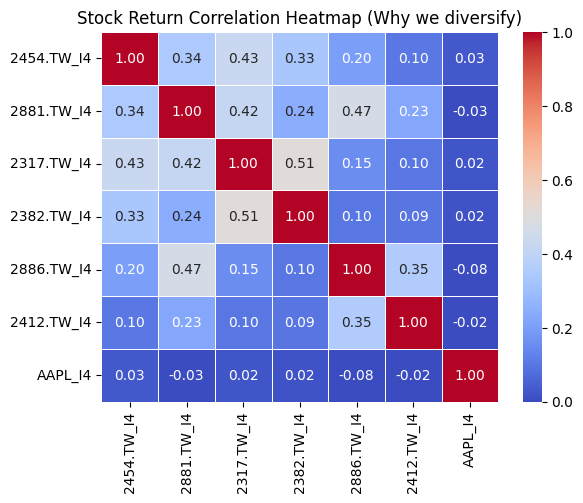

In [12]:
corr_mat = all_features[[f'{s}_I4' for s in selected]].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1, linewidths=.5)
plt.title('Stock Return Correlation Heatmap (Why we diversify)')
plt.show()


股票代碼       | 建議比例      
----------------------------------------
2454.TW    |    30.00%
2881.TW    |    30.00%
2317.TW    |    10.34%
2382.TW    |     5.21%
2886.TW    |    21.77%
2412.TW    |     1.10%
AAPL       |     1.57%


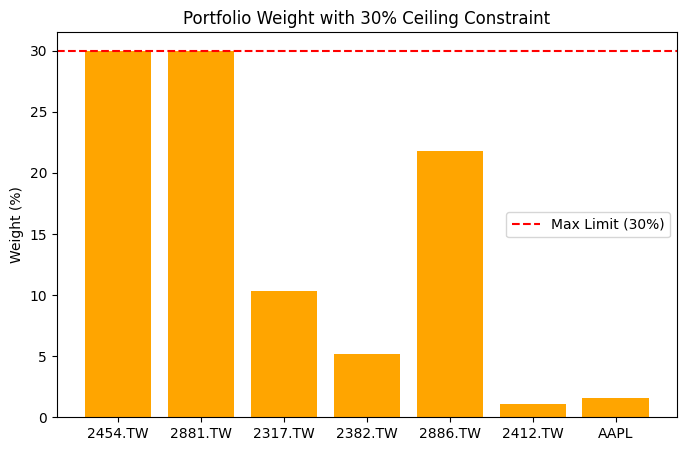

In [8]:

    best_idx = np.argmax(results[2]) #最優化夏普
    final_weights = weights_record[best_idx]

    print("\n" + "="*40)
    print(f"{'股票代碼':10} | {'建議比例':10}")
    print("-" * 40)
    for i, s in enumerate(selected):
        print(f"{s:10} | {final_weights[i]*100:8.2f}%")
    print("="*40)

    # 畫圖確認權重分佈
    plt.figure(figsize=(8, 5))
    plt.bar(selected, final_weights * 100, color='orange')
    plt.axhline(y=30, color='red', linestyle='--', label='Max Limit (30%)')
    plt.title('Portfolio Weight with 30% Ceiling Constraint')
    plt.ylabel('Weight (%)')
    plt.legend()
    plt.show()

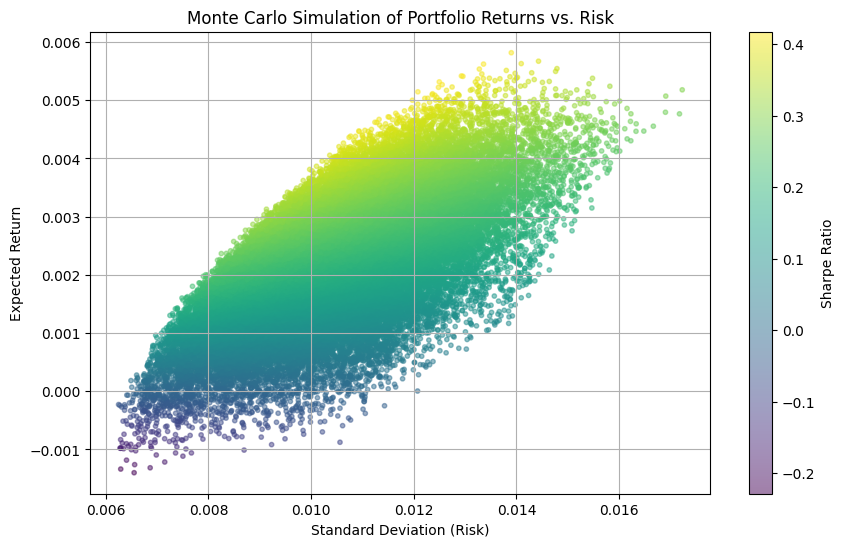

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.title('Monte Carlo Simulation of Portfolio Returns vs. Risk')
plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()